<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C19/C19_Script01_EstadisticaInferencial_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Definicion del modelo $Y = X\beta + \epsilon$

* $Y \in \mathbb{R}^n$ (Vector de respuesta)
* $X \in \mathbb{R}^{n \times p}$ (matriz de diseño con columna de unos)
* $\beta \in \mathbb{R}^p$ (Vector de parametros)
* $\epsilon \sim N(0,\sigma^2I_n)$ (Supuestos gaussianos)

Con esta informacion, podemos calcular una aproximacion del vector de parametros

$$\hat{\beta} = (X^TX)^{-1}X^{T}Y$$

In [45]:
# Simulacion del proceso de estimacion
import numpy as np
import pandas as pd

# Simulacion fundamental : Generacion de datos verdaderos
np.random.seed(42)
n = 100
p = 3 # 2 predictores + 1 intercepto

# Definicion de la matriz de diseño con correlacion controlada
X = np.random.multivariate_normal(
    mean = [0, 0], # vector de medias poblacionales
    cov =  [[1,0.7],[0.7,1]], # MATRIZ DE COVARIANZA POBLACIONAL
    size = n
)

X_design = np.column_stack([np.ones(n), X])

# Parametros verdaderos
beta_true = np.array([2,3,1.5])
sigma_true =  0.5

# Generacion del modelo con error gaussiano
epsilon = np.random.normal(0, sigma_true, n)
y = X_design @ beta_true + epsilon

# Estimacion MCO manual (matricialmente)
beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

print("=== Estimacion manual MCO ===")
print(f" beta verdadero {beta_true}")
print(f" beta estimado {beta_hat}")
print(f"Error Estandar {np.sqrt(np.mean((y - X_design@beta_hat)**2))}")

=== Estimacion manual MCO ===
 beta verdadero [2.  3.  1.5]
 beta estimado [2.04639669 3.05940094 1.33716644]
Error Estandar 0.5267909169290189


In [47]:
# Descomposicion espectral de la matriz de covarianzas : X
sigma = [[1 , 0.7],[0.7,1]]
eigenvalores, eigenvectores = np.linalg.eig(sigma)

# Mostremos la descomposicion espectral
print(f"Autovalores : {eigenvalores}")
print(f"Autovectores : \n{eigenvectores}")
print(f"Correlacion teorica {sigma[0][1]/np.sqrt(sigma[0][0] * sigma[1][1])}")

# Relacion con la descomposicion de cholesky
L = np.linalg.cholesky(sigma)
print(f"Matriz de Cholesky\n {L}")
print(f"Verificacion LL^T = sigma\n { L @ L.T}")

Autovalores : [1.7 0.3]
Autovectores : 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Correlacion teorica 0.7
Matriz de Cholesky
 [[1.         0.        ]
 [0.7        0.71414284]]
Verificacion LL^T = sigma
 [[1.  0.7]
 [0.7 1. ]]


# Consecuencias en la varianza de $\hat{\beta}$

La varianza del estimador MCO es : $Var(\hat{\beta}) = \sigma^2(X^T X)^{-1}$

In [48]:
# Calculo manual de var(beta) y descomposicion
residuos = y - X_design @ beta_hat
sigma2_estimado = np.sum(residuos**2)/(n-p)
var_beta_hat = sigma2_estimado *np.linalg.inv(X_design.T @ X_design)

print("=== Matriz de covariande de Beta_hat")
print(var_beta_hat)

# Extraer las varianzas y VIF
varianzas = np.diag(var_beta_hat)
errores_std = np.sqrt(varianzas)

# Estimacion empirica de la matriz de covarianza muestral
X_sample = X_design[:, 1:]
sigma_hat = (X_sample.T @ X_sample)/n
vif_manual = np.diag(np.linalg.inv(X_sample.T @ X_sample)) * np.var(X_sample, axis = 0)

# Mostremos
print(f"\n Errores Estandar {errores_std}")
print(f"VIF manual {vif_manual}")

=== Matriz de covariande de Beta_hat
[[ 0.00291782 -0.00010561 -0.00039293]
 [-0.00010561  0.00583967 -0.00367209]
 [-0.00039293 -0.00367209  0.00614581]]

 Errores Estandar [0.05401682 0.07641771 0.07839524]
VIF manual [0.01600786 0.01588043]


In [49]:
# Validemos con statsmodels
import statsmodels.api as sm
model_full = sm.OLS(y, X_design).fit()
model_full.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,2.0464,0.054,37.884,0.000,1.939,2.154
x1,3.0594,0.076,40.035,0.000,2.908,3.211
x2,1.3372,0.078,17.057,0.000,1.182,1.493


# Significancia de `cov = [[1, 0.7], [0.7,1]]` en MCO

## Multicolinealidad estructural vs Aleatoriedad

El parámetro `cov` control el grado de multicolinealidad en el diseño experimental.

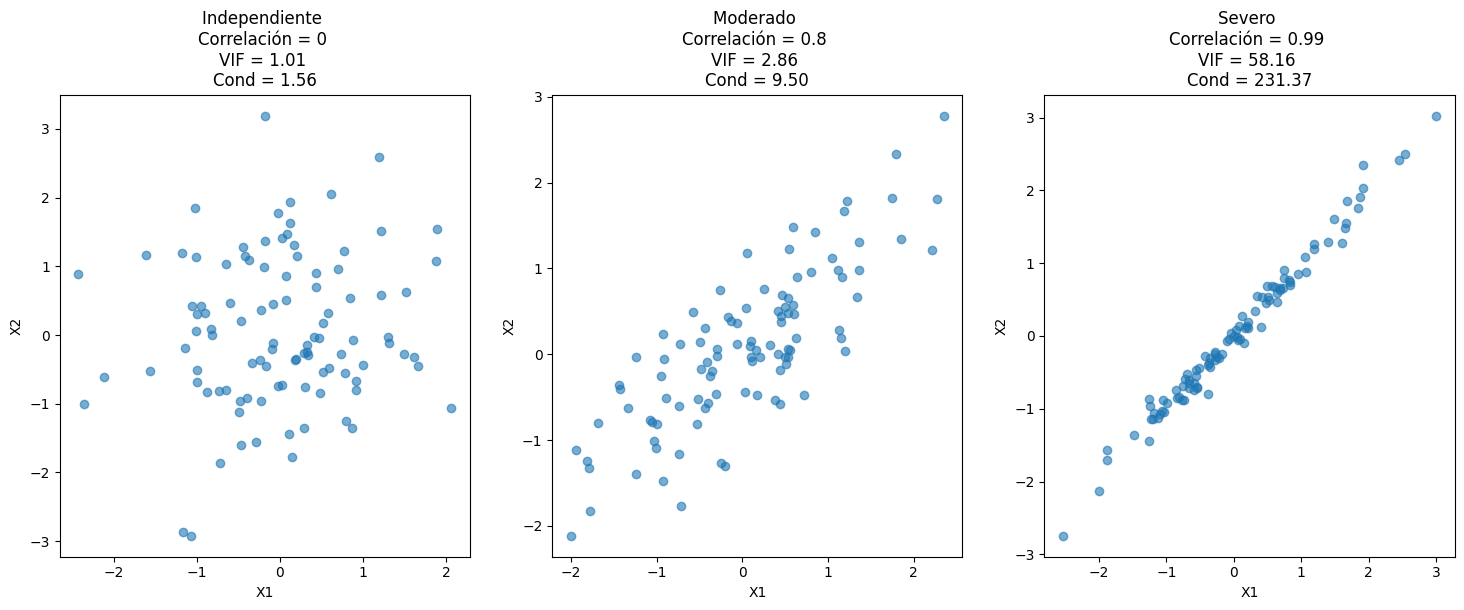

In [53]:
# Comparemos 3 escenarios : correlacion 0 vs 0.7 vs 0.99
escenarios = {
  "Independiente" : np.array([[1,0],[0,1]]),
  "Moderado" : np.array([[1,0.8],[0.8,1]]),
  "Severo" : np.array([[1,0.99],[0.99,1]])
}

# Matriz de graficos
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize = (18,6))

for i,(nombre,cov_escenario) in enumerate(escenarios.items()):

    # Generacion de datos
    X_esc = np.random.multivariate_normal([0,0], cov_escenario, n )
    X_design_esc = np.column_stack([np.ones(n), X_esc])

    # Estimacion
    beta_hat_esc = np.linalg.inv(X_design_esc.T @ X_design_esc) @ X_design_esc.T @ y

    # Calculemos metricas
    vif1 = 1/(1- np.corrcoef(X_esc[:,0],X_esc[:,1])[0,1]**2)
    cond = np.linalg.cond(X_design_esc.T @X_design_esc)

    # Visualización como un diagrama de dispersión
    axes[i].scatter(X_esc[:,0], X_esc[:,1], alpha = 0.6)
    axes[i].set_title(f"{nombre} \nCorrelación = {cov_escenario[0,1]} \nVIF = {vif1:.2f} \nCond = {cond:.2f}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")

In [11]:
# Agregar un outlier a la matriz de diseño para ver como "explota" el numero
# de condion.
# Notar que si el numero de condicion (np.linalg.cond) es superior a 10**12 (10**15)
# entonces es mejor utilizar metodos de optimizacion para el calculo de los parametros (beta_hat)

## Interpretación geométrica en el espacio de columnas

La correlación altera el ángulo entre columnas de X, afectando la ortogonalidad de la proyección    


In [27]:
# Geometría del espacio columna
from scipy.linalg import orth

# Base ortonormal del espacio columna
Q = orth(X_design)

# Ángulo entre columnas
cos_angle = X_design[:,1] @ X_design[:,2] / (np.linalg.norm(X_design[:,1]) * np.linalg.norm(X_design[:,2]))
angle_degrees = np.degrees(np.arccos(cos_angle))

# Mostremos
print(f"Ángulo entre X1 y X2: {angle_degrees:.2f} grados")
print(f"Coseno (ángulo) = Correlación muestral aproximada {cos_angle}")
print(f"Ortogonalidad {"Perfecta" if np.abs(cos_angle) < 0.01 else "Aproximada" if np.abs(cos_angle) < 0.3 else "Colineal"}")

Ángulo entre X1 y X2: 51.82 grados
Coseno (ángulo) = Correlación muestral aproximada 0.6181992460395157
Ortogonalidad Colineal


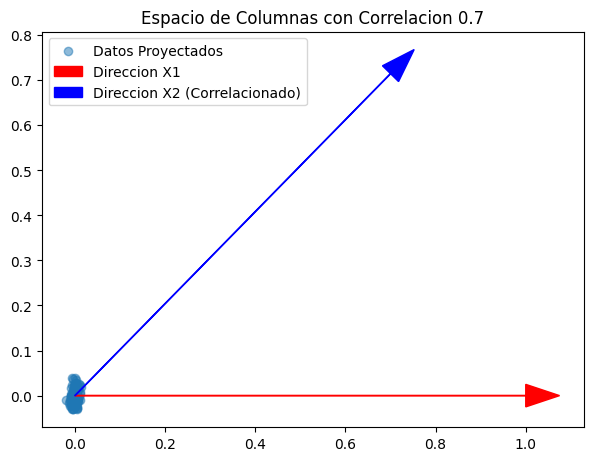

In [55]:
# Visualizacion 2D del espacio de columnas
fig, ax = plt.subplots(figsize = (7,7))

X_proj = X_design[:,1:] @ np.linalg.inv(X_design[:,1:].T @ X_design[:,1:]) @ X_design[:,1:].T
ax.scatter(X_proj[:,0] , X_proj[:,1], alpha = 0.5, label = "Datos Proyectados")
ax.arrow(0,0,1,0 , head_width = 0.05, color = "red", label = "Direccion X1")
ax.arrow(0,0,0.7, np.sqrt(1-0.7**2), head_width = 0.05, color = "blue", label = "Direccion X2 (Correlacionado)")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Espacio de Columnas con Correlacion 0.7")
plt.show()

## Impacto en la eficiencia del estimado y diseño óptimo

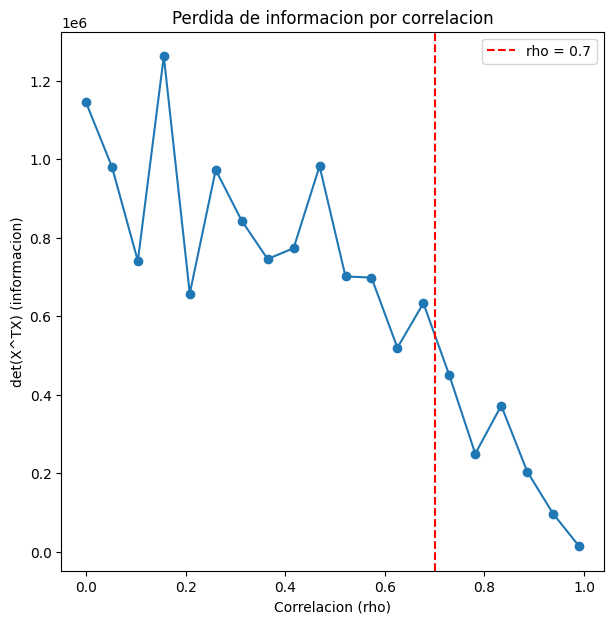

Diseño Óptimo
det(X^T X) optimo (rho = 0) = 1145171.92
det(X^T X) actual (rho = 0.7) = 633209.37
Perdida de información 44.70617443372779%


In [60]:
# Criterio D-optimo : maximizar det(X^T X)
dets = []
correlaciones = np.linspace(0,0.99,20)

for rho in correlaciones:
    sigma_rho = np.array([[1,rho],[rho,1]])
    X_rho = np.random.multivariate_normal([0,0], sigma_rho, n)
    X_design_rho = np.column_stack([np.ones(n), X_rho])
    dets.append(np.linalg.det(X_design_rho.T @ X_design_rho))

# Visulizacion de la perdida de informacion
fig,ax = plt.subplots(figsize = (7,7))
ax.plot(correlaciones, dets , "o-")
ax.axvline(x = 0.7, color = "red", linestyle = "--", label = "rho = 0.7")
ax.set_xlabel("Correlacion (rho)")
ax.set_ylabel("det(X^TX) (informacion)")
ax.set_title("Perdida de informacion por correlacion")
ax.legend()
plt.show()

# Calculo de la perdida relativa
det_optimo = dets[0] # rho = 0
det_actual = dets[np.argmin(np.abs(correlaciones - 0.7))]
print("Diseño Óptimo")
print(f"det(X^T X) optimo (rho = 0) = {det_optimo:.2f}")
print(f"det(X^T X) actual (rho = 0.7) = {det_actual:.2f}")
print(f"Perdida de información {(1 - det_actual/det_optimo)*100}%")

# Descomposición de la varianza y ANOVA en regresión

**Fundamento**: La suma de cuadrados totales (SST) se descompone en
$$
SST = SSR + SSE
$$

+ $SST =\sum(y_i - \bar{y})^2$ (Varianza Total): Es la inercia total del vector de respuesta $Y$ respecto a su centro de gravedad $(\bar{Y})$. Mide la variabilidad total sin explicar.
+ $SSR = \sum(\hat{y}_i - \bar{y})^2$ (Varianza Explicada): Representa la proyección de $Y$ sobre el subespacio $\mathcal{C}X$
+ $SSE = \sum(y_i - \hat{y}_i)^2$ (Varianza No Explicada)

In [61]:
# Fundamentos de ANOVA
y_pred = X_design @ beta_hat
y_mean = np.mean(y)

# Suma de cuadrados
SST = np.sum((y - y_mean)**2)
SSR = np.sum((y_pred - y_mean)**2)
SSE = np.sum((y - y_pred)**2)

# Grados de libertad de regresión
df_regression = p - 1

# Grados de libertad de residuos
df_residual = n - p

# Estadístico F
f_statistic = (SSR/df_regression) / (SSE/df_residual)

# R cuadrado R²
R2 = SSR/SST

print(f"SST: {SST:.2f} → Varianza Total")
print(f"SSR: {SSR:.2f} → Varianza Explicada")
print(f"SSE: {SSE:.2f} → Varianza No Explicada")
print(f"Estadístico - F: {f_statistic:.2f}")
print(f"R cuadrado: {R2:.2f}")

# Validación con statsmodels
import statsmodels.api as sm
model = sm.OLS(y,  X_design).fit()
print(model.summary())

SST: 1279.24 → Varianza Total
SSR: 1251.49 → Varianza Explicada
SSE: 27.75 → Varianza No Explicada
Estadístico - F: 2187.22
R cuadrado: 0.98
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     2187.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.05e-81
Time:                        22:56:54   Log-Likelihood:                -77.799
No. Observations:                 100   AIC:                             161.6
Df Residuals:                      97   BIC:                             169.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025   